# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: Inicialmente, os dados são importados de um arquivo CSV e passam por uma etapa de pré-processamento, na qual uma coluna é definida como índice e o DataFrame é transposto. Em seguida, as colunas são renomeadas com descrições claras, permitindo melhor interpretação das variáveis analisadas. A partir disso, o programa realiza o cálculo da frequência dos tamanhos dos genes, contando quantas vezes cada valor aparece na coluna correspondente e organizando esses valores em ordem crescente. Esse passo é fundamental, pois permite identificar como os tamanhos estão distribuídos no conjunto de dados. Posteriormente, a frequência calculada é convertida em uma tabela estruturada, facilitando sua visualização e interpretação. Além disso, essa informação é integrada ao DataFrame original por meio da criação de uma nova coluna, que associa a cada gene a frequência do seu tamanho. Isso preserva a organização original dos dados ao mesmo tempo em que adiciona uma camada de análise estatística. Por fim, o programa apresenta os resultados de forma gráfica, utilizando um gráfico de barras que relaciona os tamanhos dos genes com suas respectivas frequências. Dessa forma, o racional da resposta está na construção de um fluxo que parte da organização dos dados, passa pela análise estatística da frequência e culmina na visualização, permitindo compreender de maneira clara como os tamanhos dos genes se distribuem.


## 02 – Desenhe o fluxograma da resposta:

<img src = "exercicio2aula13.png" width="400" />

## 03 – Escreva o programa em Python:

In [75]:
import pandas as pd
exercicio1aula13 = pd.read_csv('dataframe_genes.csv')
exercicio1aula13 = exercicio1aula13.set_index('Unnamed: 0')
exercicio1aula13 = exercicio1aula13.T
exercicio1aula13.columns = [
    'Nome do gene',
    'Tamanho do gene',
    'Início do nome do gene',
    "Número de A's no nome do gene",
    'HU no nome do gene'
]

exercicio1aula13 

,Nome do gene,Tamanho do gene,Início do nome do gene,Número de A's no nome do gene,HU no nome do gene
BRCA1,BRCA1,5,BR,1,False
CDKN2A,CDKN2A,6,CD,1,False
TP53,TP53,4,TP,0,False
KRAS,KRAS,4,KR,1,False
SMAD4,SMAD4,5,SM,1,False


In [76]:
frequencia = exercicio1aula13['Tamanho do gene'].value_counts().sort_index()
tabela_freq = frequencia.reset_index()
tabela_freq.columns = ['Tamanho do gene', 'Frequência']
exercicio1aula13['Frequência do tamanho'] = exercicio1aula13['Tamanho do gene'].map(frequencia)
exercicio1aula13

,Nome do gene,Tamanho do gene,Início do nome do gene,Número de A's no nome do gene,HU no nome do gene,Frequência do tamanho
BRCA1,BRCA1,5,BR,1,False,2
CDKN2A,CDKN2A,6,CD,1,False,1
TP53,TP53,4,TP,0,False,2
KRAS,KRAS,4,KR,1,False,2
SMAD4,SMAD4,5,SM,1,False,2


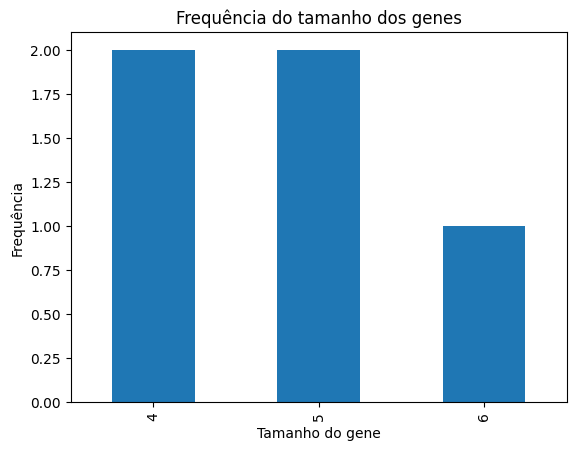

In [77]:
import matplotlib.pyplot as plt

frequencia.plot(kind='bar')
plt.xlabel('Tamanho do gene')
plt.ylabel('Frequência')
plt.title('Frequência do tamanho dos genes')
plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que há uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: O programa tem como objetivo analisar a frequência acumulada dos tamanhos dos genes ao longo da ordem original em que aparecem no conjunto de dados. Inicialmente, parte-se de um DataFrame previamente estruturado, denominado exercicio4aula13, que contém uma coluna correspondente aos tamanhos dos genes. Em um primeiro momento, o código apresenta uma tentativa de cálculo de frequência acumulada por meio da função expanding(), que considera progressivamente os valores desde o início até cada ponto da série, aplicando uma contagem de ocorrências. Entretanto, esse resultado não é utilizado nas etapas posteriores, não contribuindo efetivamente para o fluxo principal da análise. Na sequência, realiza-se o cálculo central do programa utilizando a função groupby, que agrupa os dados de acordo com os tamanhos dos genes. A partir disso, a função cumcount() é aplicada para contabilizar quantas vezes cada tamanho já apareceu até determinada posição no DataFrame. Ao adicionar 1 ao resultado, obtém-se uma contagem acumulada iniciando em 1, a qual é armazenada em uma nova coluna denominada frequência acumulada. Esse procedimento é fundamental, pois permite acompanhar a recorrência de cada tamanho de gene ao longo da sequência original dos dados, sem alterar sua organização. Por fim, o programa realiza a visualização dos resultados por meio de um gráfico de barras, no qual cada gene, respeitando sua posição original, é associado à sua respectiva frequência acumulada. São definidos rótulos para os eixos e um título para o gráfico, garantindo melhor interpretação das informações apresentadas. Dessa forma, o racional do programa baseia-se na preservação da ordem dos dados, no cálculo progressivo da frequência dos tamanhos dos genes e na representação gráfica desses resultados, permitindo uma compreensão clara da distribuição ao longo do conjunto analisado.


## 05 – Desenhe o fluxograma da resposta:

<img src = "exercicio5aula13.png" width="400" />

## 06 – Escreva o programa em Python:

In [78]:
exercicio4aula13 = exercicio1aula13

exercicio4aula13 

,Nome do gene,Tamanho do gene,Início do nome do gene,Número de A's no nome do gene,HU no nome do gene,Frequência do tamanho
BRCA1,BRCA1,5,BR,1,False,2
CDKN2A,CDKN2A,6,CD,1,False,1
TP53,TP53,4,TP,0,False,2
KRAS,KRAS,4,KR,1,False,2
SMAD4,SMAD4,5,SM,1,False,2


In [79]:
import matplotlib.pyplot as plt

frequencia_acumulada = exercicio4aula13['Tamanho do gene'].expanding().apply(lambda x: x.value_counts().iloc[0])

exercicio4aula13['Frequência acumulada'] = (
    exercicio4aula13.groupby('Tamanho do gene').cumcount() + 1
)
exercicio4aula13

,Nome do gene,Tamanho do gene,Início do nome do gene,Número de A's no nome do gene,HU no nome do gene,Frequência do tamanho,Frequência acumulada
BRCA1,BRCA1,5,BR,1,False,2,1
CDKN2A,CDKN2A,6,CD,1,False,1,1
TP53,TP53,4,TP,0,False,2,1
KRAS,KRAS,4,KR,1,False,2,2
SMAD4,SMAD4,5,SM,1,False,2,2


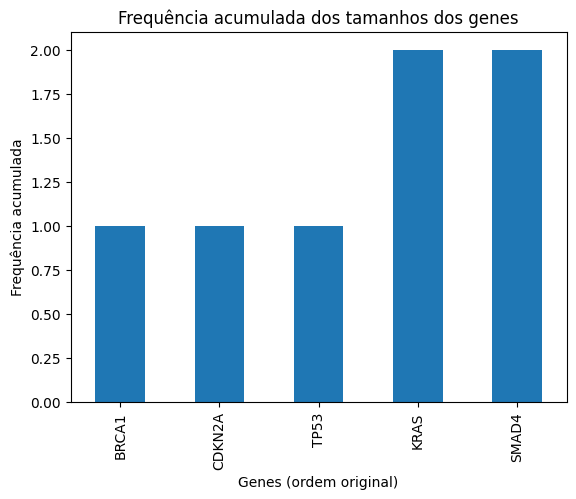

In [80]:
frequencia_acumulada.plot(kind='bar')
plt.xlabel('Genes (ordem original)')
plt.ylabel('Frequência acumulada')
plt.title('Frequência acumulada dos tamanhos dos genes')
plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [81]:
exercicio4aula13 = exercicio4aula13.drop(columns=['Início do nome do gene', "Número de A's no nome do gene", 'HU no nome do gene'])

In [82]:
exercicio4aula13['Amostras'] = "Amostra 1"

In [83]:
exercicio4aula13 

,Nome do gene,Tamanho do gene,Frequência do tamanho,Frequência acumulada,Amostras
BRCA1,BRCA1,5,2,1,Amostra 1
CDKN2A,CDKN2A,6,1,1,Amostra 1
TP53,TP53,4,2,1,Amostra 1
KRAS,KRAS,4,2,2,Amostra 1
SMAD4,SMAD4,5,2,2,Amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [84]:
import numpy as np 

In [85]:
exercicio4aula13['Amostra 2'] = np.random.randint(1, 10, 5)

In [86]:
exercicio4aula13['Freq Acum A2'] = (
    exercicio4aula13.groupby('Amostra 2').cumcount() + 1
)
exercicio4aula13

,Nome do gene,Tamanho do gene,Frequência do tamanho,Frequência acumulada,Amostras,Amostra 2,Freq Acum A2
BRCA1,BRCA1,5,2,1,Amostra 1,2,1
CDKN2A,CDKN2A,6,1,1,Amostra 1,3,1
TP53,TP53,4,2,1,Amostra 1,5,1
KRAS,KRAS,4,2,2,Amostra 1,4,1
SMAD4,SMAD4,5,2,2,Amostra 1,4,2


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [87]:
exercicio4aula13['Amostra 3'] = np.random.randint(1, 10, 5)
exercicio4aula13['Freq Acum A3'] = (
    exercicio4aula13.groupby('Amostra 3').cumcount() + 1
)
exercicio4aula13['Amostra 4'] = np.random.randint(1, 10, 5)
exercicio4aula13['Freq Acum A4'] = (
    exercicio4aula13.groupby('Amostra 4').cumcount() + 1
)
exercicio4aula13['Amostra 5'] = np.random.randint(1, 10, 5)
exercicio4aula13['Freq Acum A5'] = (
    exercicio4aula13.groupby('Amostra 5').cumcount() + 1
)
exercicio4aula13['Amostra 6'] = np.random.randint(1, 10, 5)
exercicio4aula13['Freq Acum A6'] = (
    exercicio4aula13.groupby('Amostra 6').cumcount() + 1
)
exercicio4aula13

,Nome do gene,Tamanho do gene,Frequência do tamanho,Frequência acumulada,Amostras,Amostra 2,Freq Acum A2,Amostra 3,Freq Acum A3,Amostra 4,Freq Acum A4,Amostra 5,Freq Acum A5,Amostra 6,Freq Acum A6
BRCA1,BRCA1,5,2,1,Amostra 1,2,1,9,1,2,1,9,1,3,1
CDKN2A,CDKN2A,6,1,1,Amostra 1,3,1,5,1,5,1,3,1,1,1
TP53,TP53,4,2,1,Amostra 1,5,1,7,1,3,1,6,1,7,1
KRAS,KRAS,4,2,2,Amostra 1,4,1,6,1,6,1,4,1,9,1
SMAD4,SMAD4,5,2,2,Amostra 1,4,2,9,2,5,2,6,2,8,1


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

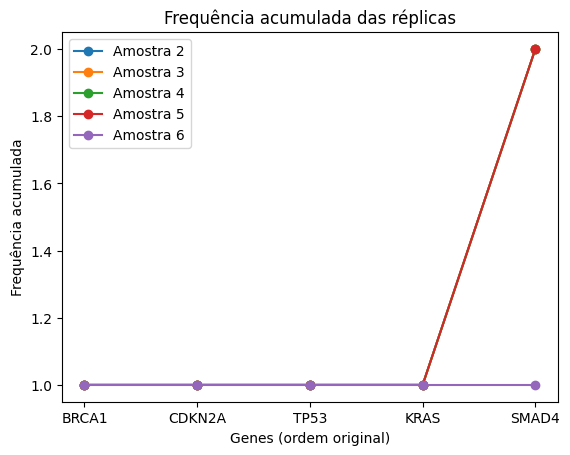

In [88]:
plt.plot(exercicio4aula13['Freq Acum A2'], marker='o', label='Amostra 2')
plt.plot(exercicio4aula13['Freq Acum A3'], marker='o', label='Amostra 3')
plt.plot(exercicio4aula13['Freq Acum A4'], marker='o', label='Amostra 4')
plt.plot(exercicio4aula13['Freq Acum A5'], marker='o', label='Amostra 5')
plt.plot(exercicio4aula13['Freq Acum A6'], marker='o', label='Amostra 6')


plt.xlabel('Genes (ordem original)')
plt.ylabel('Frequência acumulada')
plt.title('Frequência acumulada das réplicas')
plt.legend()

plt.show()